In [9]:
pip install torch torchvision matplotlib

In [10]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(100,256),
            nn.ReLU(),
            nn.Linear(256,512),
            nn.ReLU(),
            nn.Linear(512,784),
            nn.Tanh()
        )

    def forward(self,x):
        return self.model(x)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784,512),
            nn.LeakyReLU(0.2),
            nn.Linear(512,256),
            nn.LeakyReLU(0.2),
            nn.Linear(256,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(),lr=0.0002)
optimizer_D = torch.optim.Adam(D.parameters(),lr=0.0002)

epochs = 20

for epoch in range(epochs):

    for imgs,_ in loader:

        real_imgs = imgs.view(-1,784).to(device)
        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size,1).to(device)
        fake_labels = torch.zeros(batch_size,1).to(device)

        # Train D
        outputs = D(real_imgs)
        d_real_loss = criterion(outputs,real_labels)

        z = torch.randn(batch_size,100).to(device)
        fake_imgs = G(z)

        outputs = D(fake_imgs.detach())
        d_fake_loss = criterion(outputs,fake_labels)

        d_loss = d_real_loss + d_fake_loss

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # Train G
        outputs = D(fake_imgs)

        g_loss = criterion(outputs,real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] D:{d_loss.item():.4f} G:{g_loss.item():.4f}")

Epoch [1/20] D:0.0385 G:4.6279
Epoch [2/20] D:0.0280 G:5.8462
Epoch [3/20] D:0.0190 G:7.6405
Epoch [4/20] D:0.0837 G:7.1496
Epoch [5/20] D:0.0424 G:6.6505
Epoch [6/20] D:0.2324 G:5.0183
Epoch [7/20] D:0.1289 G:5.0687
Epoch [8/20] D:0.2364 G:3.5063
Epoch [9/20] D:0.3279 G:4.5638
Epoch [10/20] D:0.1946 G:3.5061
Epoch [11/20] D:0.4674 G:2.9178
Epoch [12/20] D:0.2651 G:3.1467
Epoch [13/20] D:0.3866 G:3.3557
Epoch [14/20] D:0.3270 G:3.0946
Epoch [15/20] D:0.5166 G:2.6417
Epoch [16/20] D:0.3457 G:3.9716
Epoch [17/20] D:0.5412 G:3.1969
Epoch [18/20] D:0.6640 G:2.7681
Epoch [19/20] D:0.7222 G:2.0210
Epoch [20/20] D:0.8884 G:2.8206


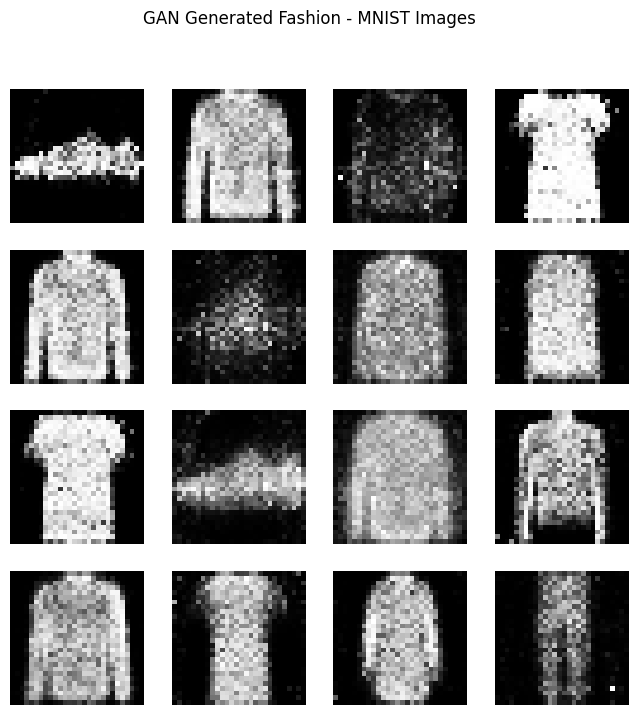

In [11]:
import matplotlib.pyplot as plt
import torch
#generate images
G.eval()
with torch.no_grad():
  z=torch.randn(16,100).to(device)
  generated_images=G(z)
generated_images = generated_images.view(-1,28,28)

#plot
fig,axes= plt.subplots(4,4,figsize=(8,8))
for i,ax in enumerate(axes.flat):
  ax.imshow(generated_images[i],cmap='gray')
  ax.axis('off')
plt.suptitle("GAN Generated Fashion - MNIST Images")
plt.show()



In [12]:
from torchvision.utils import save_image
generated_images=generated_images.unsqueeze(1)
save_image(generated_images,
           "gan_generated.png",
           nrow=4,
           normalize=True
)

Diffusers

In [13]:
!pip install diffusers transformers accelerate torch torchvision matplotlib tqdm

In [14]:
import torch
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from diffusers import UNet2DModel
from diffusers import DDPMScheduler
from tqdm import tqdm

In [15]:
device=torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Running on: ",device)

Running on:  cpu


In [16]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True
)

print("Dataset Loaded")

Dataset Loaded


In [17]:
model = UNet2DModel(
    sample_size=28,
    in_channels=1,
    out_channels=1,

    layers_per_block=1,

    block_out_channels=(32, 64),

    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D"
    ),

    up_block_types=(
        "AttnUpBlock2D",
        "UpBlock2D"
    )
).to(device)

print("Model Created")

Model Created


In [18]:
noise_Scheduler = DDPMScheduler(
    num_train_timesteps=50
)

In [19]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

In [20]:
epochs = 3

for epoch in range(epochs):

    progress_bar = tqdm(loader)

    for images, _ in progress_bar:

        images = images.to(device)

        noise = torch.randn_like(images)

        timesteps = torch.randint(
            0,
            noise_Scheduler.config.num_train_timesteps,
            (images.shape[0],),
            device=device
        ).long()

        noisy_images = noise_Scheduler.add_noise(
            images,
            noise,
            timesteps
        )

        noise_pred = model(
            noisy_images,
            timesteps
        ).sample

        loss = torch.nn.functional.mse_loss(
            noise_pred,
            noise
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        progress_bar.set_description(
            f"Epoch {epoch+1} Loss {loss.item():.4f}"
        )

print("Training Complete")

Epoch 3 Loss 0.1578: 100%|██████████| 938/938 [35:07<00:00,  2.25s/it]

Training Complete


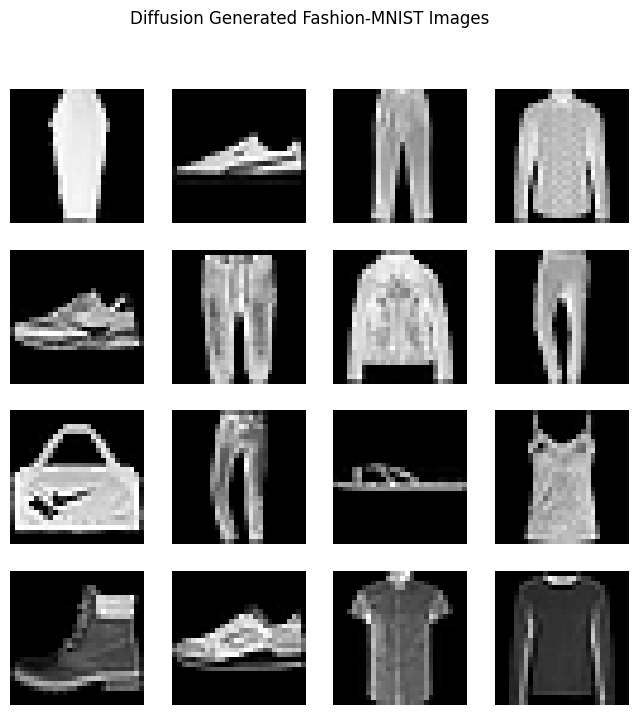

In [21]:
images = images.cpu()

fig, axes = plt.subplots(
    4,
    4,
    figsize=(8,8)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        images[i][0],
        cmap="gray"
    )

    ax.axis("off")

plt.suptitle(
    "Diffusion Generated Fashion-MNIST Images"
)

plt.show()

In [22]:
from torchvision.utils import save_image

save_image(
    images,
    "diffusion_output.png",
    nrow=4,
    normalize=True
)

print("Saved as diffusion_output.png")

Saved as diffusion_output.png
